#TASK1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = sns.load_dataset("titanic")
print("dataset loaded succesfully!!")

dataset loaded succesfully!!


In [ ]:
print("DATASET INFO:")
df.info()
print("\n DESCRIPTIVE STATISTICS:")
print(df.describe())
print("\n DATASET SHAPE:")
print(df.shape)

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

 DESCRIPTIVE STATISTICS:
         survived      pclass         a

In [ ]:
missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)
missing_percentage = missing_percentage[missing_percentage > 0]
print("Missing-value percentages:")
display(missing_percentage.to_frame("Missing %"))

Missing-value percentages:


,Missing %
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


In [ ]:
df.to_csv("titanic.csv", index=False)

print("Original Titanic dataset saved as titanic.csv")

Original Titanic dataset saved as titanic.csv


# TASK2

In [ ]:
missing_percentage = df.isnull().mean() * 100

print("Missing-value percentages:\n")

for column, percentage in missing_percentage[missing_percentage > 0].items():
    print(f"{column}: {percentage:.2f}%")

Missing-value percentages:

deck: 77.39%


In [ ]:
missing_percentage = df.isnull().mean() * 100

print("Missing-value percentages:\n")

for column, percentage in missing_percentage[missing_percentage > 0].items():
    print(f"{column}: {percentage:.2f}%")

Missing-value percentages:

deck: 77.39%


In [ ]:
# Calculate missing percentages BEFORE handling
missing_percentage = df.isnull().mean() * 100

print("Missing percentages:")
for column, percentage in missing_percentage[missing_percentage > 0].items():
    print(f"{column}: {percentage:.2f}%")

# 1. Less than 5% → Drop rows
low_missing_cols = missing_percentage[
    (missing_percentage > 0) & (missing_percentage < 5)
].index

df = df.dropna(subset=low_missing_cols)

# 2. 5%–30% → Impute
medium_missing_cols = missing_percentage[
    (missing_percentage >= 5) & (missing_percentage <= 30)
].index

for column in medium_missing_cols:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

# 3. Very high missing → Drop the column
high_missing_cols = missing_percentage[
    missing_percentage > 30
].index

df = df.drop(columns=high_missing_cols)

print("\nDropped high-missing columns:", list(high_missing_cols))

print("\nRemaining missing values:")
print(df.isnull().sum())

print("\nFinal shape:")
print(df.shape)

Missing percentages:
deck: 77.39%

Dropped high-missing columns: ['deck']

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Final shape:
(889, 14)


In [ ]:
print("Remaining missing values:\n")
print(df.isnull().sum())

print("\nDataset shape after missing-value handling:")
print(df.shape)

Remaining missing values:

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Dataset shape after missing-value handling:
(889, 14)


# TASK3

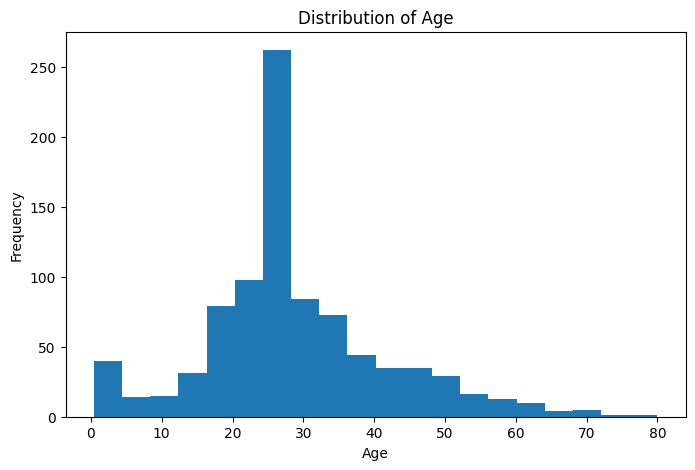

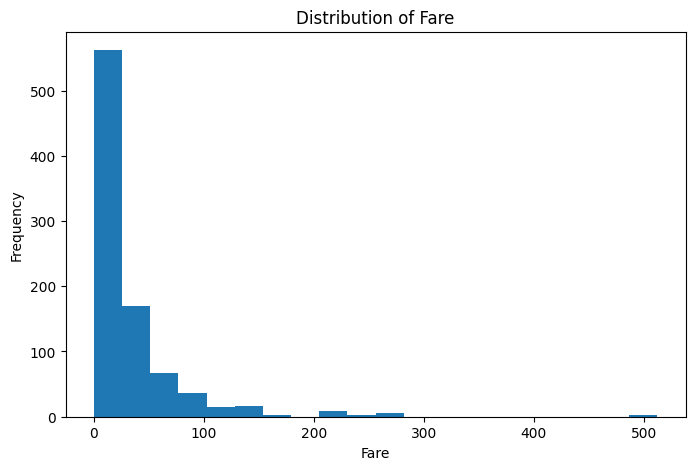

In [ ]:
import matplotlib.pyplot as plt

# Histograms
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["fare"], bins=20)
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Distribution of Fare")
plt.show()


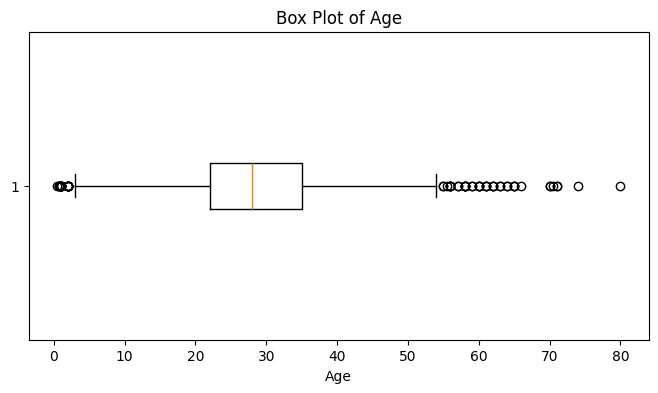

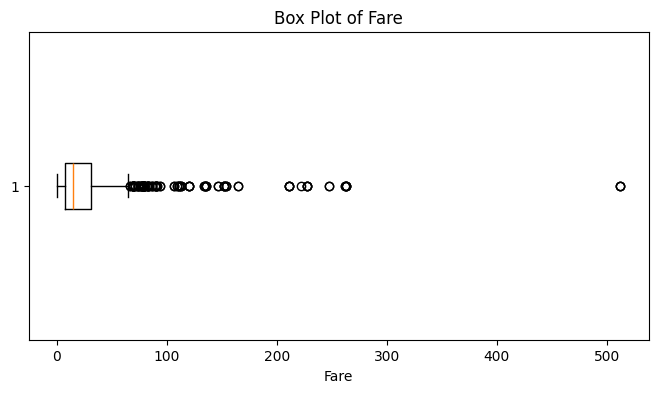

In [ ]:
# Box plots
plt.figure(figsize=(8, 4))
plt.boxplot(df["age"].dropna(), vert=False)
plt.xlabel("Age")
plt.title("Box Plot of Age")
plt.show()

plt.figure(figsize=(8, 4))
plt.boxplot(df["fare"].dropna(), vert=False)
plt.xlabel("Fare")
plt.title("Box Plot of Fare")
plt.show()

In [ ]:
def iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


# Age
age_Q1, age_Q3, age_IQR, age_lower, age_upper, age_outliers = iqr_outliers(df["age"])

# Fare
fare_Q1, fare_Q3, fare_IQR, fare_lower, fare_upper, fare_outliers = iqr_outliers(df["fare"])


print("AGE")
print("Q1:", age_Q1)
print("Q3:", age_Q3)
print("IQR:", age_IQR)
print("Lower Bound:", age_lower)
print("Upper Bound:", age_upper)
print("Number of Outliers:", age_outliers)

print("\nFARE")
print("Q1:", fare_Q1)
print("Q3:", fare_Q3)
print("IQR:", fare_IQR)
print("Lower Bound:", fare_lower)
print("Upper Bound:", fare_upper)
print("Number of Outliers:", fare_outliers)

AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 65

FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Outliers: 114


In [ ]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

print("\nOrdering:")
print(f"Mean > Median: {fare_mean > fare_median}")
print(f"Median > Mode: {fare_median > fare_mode}")

if fare_mean > fare_median > fare_mode:
    print("\nConclusion: Fare is positively (right) skewed.")
elif fare_mean < fare_median < fare_mode:
    print("\nConclusion: Fare is negatively (left) skewed.")
else:
    print("\nConclusion: Fare does not follow a simple skewness ordering.")

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05

Ordering:
Mean > Median: True
Median > Mode: True

Conclusion: Fare is positively (right) skewed.


# TASK4

In [ ]:
# Example boolean masking
female_survivors = df[(df["sex"] == "female") & (df["survived"] == 1)]

print("Number of female survivors:", len(female_survivors))


# Survival rate by Sex
survival_by_sex = df.groupby("sex")["survived"].mean() * 100

print("\nSurvival Rate by Sex:")
print(survival_by_sex)


# Survival rate by Passenger Class
survival_by_pclass = df.groupby("pclass")["survived"].mean() * 100

print("\nSurvival Rate by Passenger Class:")
print(survival_by_pclass)


# Survival rate by Sex + Passenger Class
survival_by_sex_pclass = (
    df.groupby(["sex", "pclass"])["survived"]
      .mean()
      .mul(100)
)

print("\nSurvival Rate by Sex + Passenger Class:")
print(survival_by_sex_pclass)

Number of female survivors: 231

Survival Rate by Sex:
sex
female    74.038462
male      18.890815
Name: survived, dtype: float64

Survival Rate by Passenger Class:
pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64

Survival Rate by Sex + Passenger Class:
sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [ ]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print("Correlation Matrix:")
display(corr_matrix)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


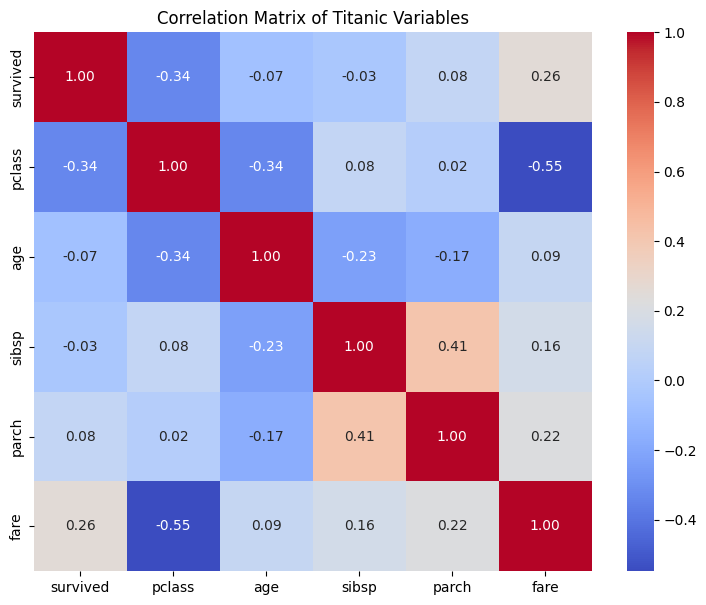

In [ ]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Titanic Variables")
plt.show()

In [ ]:
# Take absolute values
abs_corr = corr_matrix.abs()

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = abs_corr.where(
    np.triu(np.ones(abs_corr.shape), k=1).astype(bool)
)

# Find the two strongest correlations
strongest_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .head(2)
)

print("Two strongest correlations:")
print(strongest_pairs)

Two strongest correlations:
pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


# TASK5

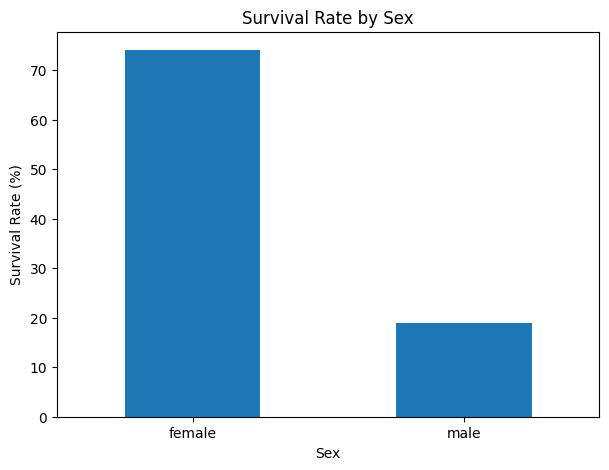

In [ ]:
survival_sex = df.groupby("sex")["survived"].mean() * 100

plt.figure(figsize=(7, 5))
survival_sex.plot(kind="bar")

plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Sex")
plt.xticks(rotation=0)
plt.show()

The survival rate differs substantially between male and female passengers. Female passengers had a considerably higher survival rate than male passengers. This indicates that sex was an important factor associated with survival in the Titanic dataset.

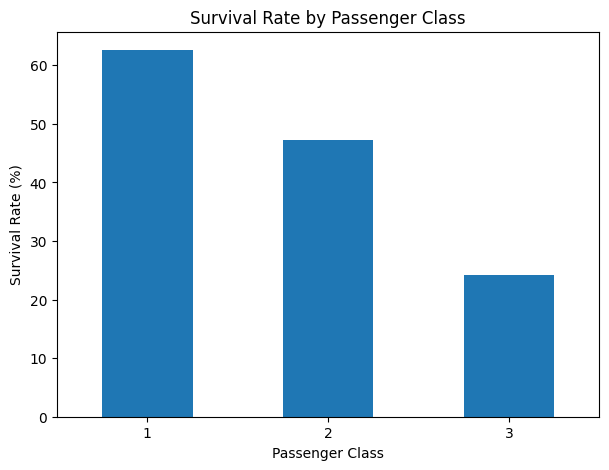

In [ ]:
survival_class = df.groupby("pclass")["survived"].mean() * 100

plt.figure(figsize=(7, 5))
survival_class.plot(kind="bar")

plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class")
plt.xticks(rotation=0)
plt.show()

Survival rates vary across passenger classes. Passengers in higher classes had higher survival rates compared with passengers in lower classes. This shows that passenger class was associated with survival and provides another important dimension for understanding the outcome.

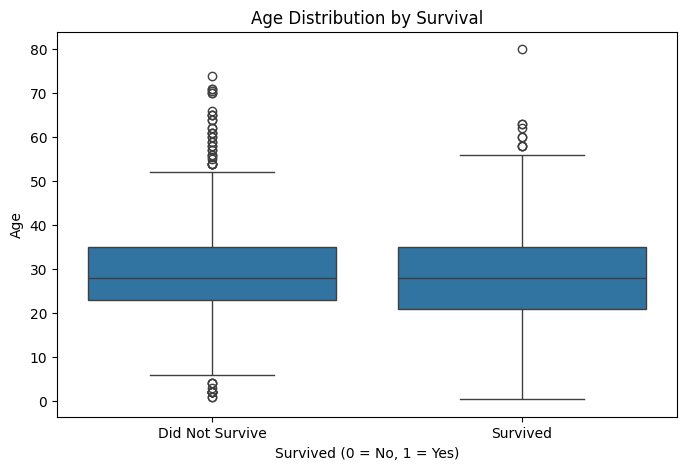

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.title("Age Distribution by Survival")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.show()

The box plot compares the age distributions of passengers who survived and those who did not. The distributions overlap considerably, indicating that age alone does not completely separate survivors from non-survivors. However, differences in the median and spread provide evidence that age was associated with survival to some extent.

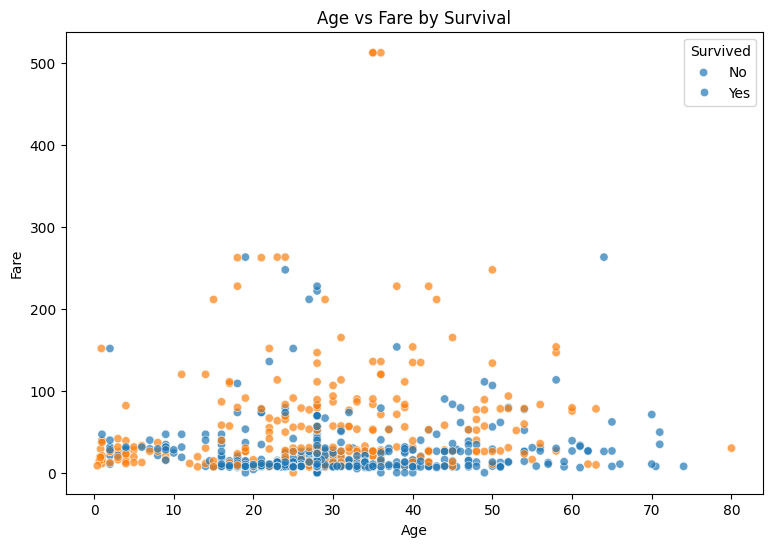

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)

plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare by Survival")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

The scatter plot combines age, fare, and survival status to show how these variables interact. Higher fares are associated with particular passenger groups, while survival status is distributed across different age and fare ranges. The plot supports the idea that survival was influenced by multiple factors rather than a single variable.

# TASK6

In [ ]:
# Standardize Age and Fare using z-score

df["age_standardized"] = (
    (df["age"] - df["age"].mean()) / df["age"].std()
)

df["fare_standardized"] = (
    (df["fare"] - df["fare"].mean()) / df["fare"].std()
)

print("Standardized columns created successfully.")

Standardized columns created successfully.


In [ ]:
print("AGE")
print("Before:")
print("Mean:", df["age"].mean())
print("Std:", df["age"].std())

print("\nAfter Standardization:")
print("Mean:", df["age_standardized"].mean())
print("Std:", df["age_standardized"].std())


print("\nFARE")
print("Before:")
print("Mean:", df["fare"].mean())
print("Std:", df["fare"].std())

print("\nAfter Standardization:")
print("Mean:", df["fare_standardized"].mean())
print("Std:", df["fare_standardized"].std())

AGE
Before:
Mean: 29.315151856017994
Std: 12.984932293690774

After Standardization:
Mean: 2.837375379019523e-16
Std: 0.9999999999999994

FARE
Before:
Mean: 32.09668087739032
Std: 49.69750431670801

After Standardization:
Mean: 1.3187801057414682e-16
Std: 0.9999999999999994
